# SPY Price Prediction using Machine Learning

## Objective: Predict if the next day price of the SPY Index will be up or down based on features created from OHLC data. 

### Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from DataTransformation.features import create_ohlc_features, correlated_features

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
                                    train_test_split,
                                    RandomizedSearchCV,
                                    TimeSeriesSplit,
                                    cross_val_score
                                    )

# Classifier
from xgboost import XGBClassifier, plot_importance, to_graphviz

# Metrics
from sklearn.metrics import (
                            accuracy_score,
                            precision_recall_curve, 
                            roc_curve, 
                            RocCurveDisplay,
                            ConfusionMatrixDisplay,
                            classification_report, 
                            confusion_matrix
                            )

import quantstats as qs


sns.set(rc={'figure.figsize': (20, 8)})
pd.options.display.float_format = "{:,.4f}".format
pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv("Data/SPYOHLC.csv")
df.columns = df.columns.str.upper()
df.head()

,DATE,CLOSE,HIGH,LOW,OPEN,VOLUME
0,2015-11-02,177.7824,177.9767,175.9065,176.0332,86270800
1,2015-11-03,178.2979,178.8556,177.1994,177.4275,95246100
2,2015-11-04,177.7571,178.7204,177.2163,178.5936,96224500
3,2015-11-05,177.5797,178.2810,176.6839,177.8163,78408700
4,2015-11-06,177.4867,177.7233,176.1516,177.2332,110471500


In [3]:
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE")

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLOSE,"2,515.0000",347.2708,132.8363,155.4388,237.8145,325.5289,426.5213,687.3900
HIGH,"2,515.0000",349.0963,133.4346,156.4929,239.8607,327.6990,428.7333,689.7000
LOW,"2,515.0000",345.1407,132.0879,153.8748,236.3026,324.1005,424.2865,684.8300
OPEN,"2,515.0000",347.2044,132.8132,154.9968,238.0654,325.5828,426.4687,688.7200
VOLUME,"2,515.0000","82,893,224.3738","41,261,918.5988","20,270,000.0000","57,543,150.0000","73,484,000.0000","95,557,900.0000","392,220,700.0000"


In [5]:
df.isnull().sum()

CLOSE     0
HIGH      0
LOW       0
OPEN      0
VOLUME    0
dtype: int64

In [6]:
# check for duplicate timestmaps
duplicates = df.index.duplicated().sum()
print("Duplicate timestamps:", duplicates)

Duplicate timestamps: 0


In [7]:
# Check index is in correct order
df.index.is_monotonic_increasing

True

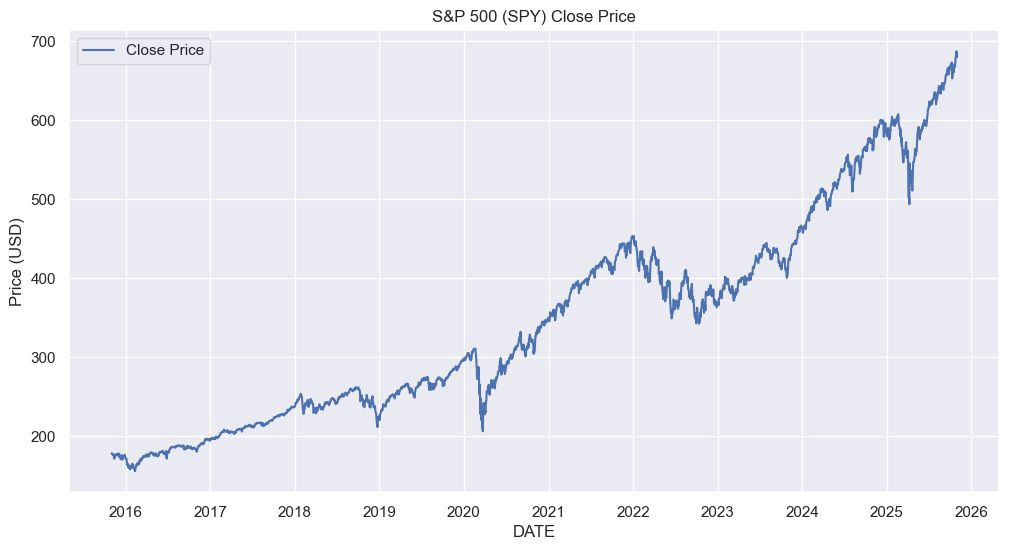

In [8]:
# Visualise the data

plt.figure(figsize=(12,6))
plt.plot(df.index, df['CLOSE'], label='Close Price')
plt.title('S&P 500 (SPY) Close Price')
plt.xlabel('DATE')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

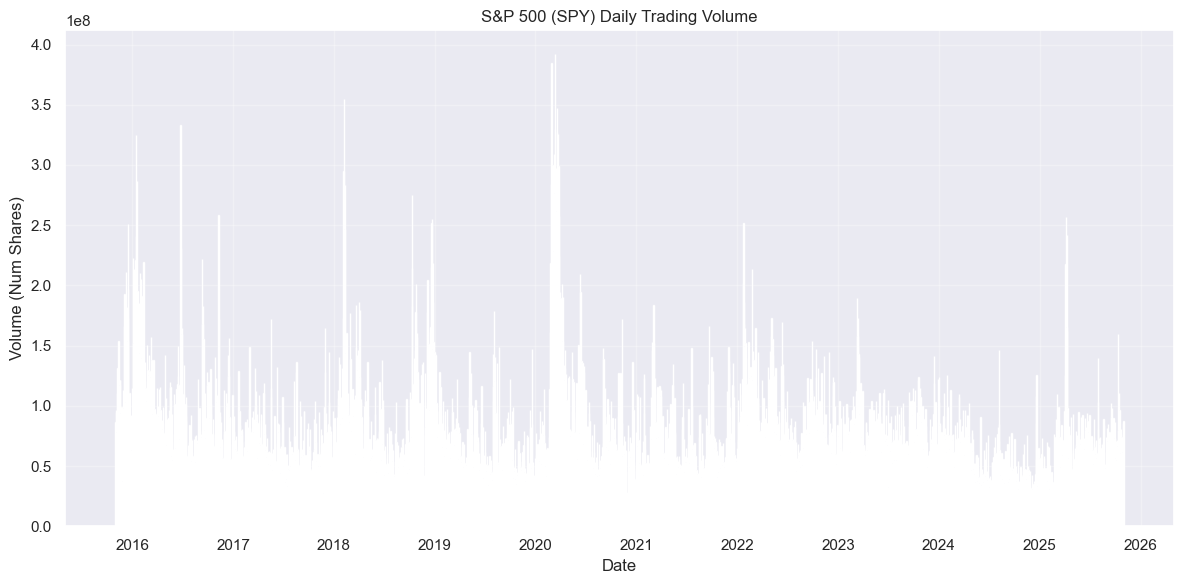

In [9]:
# Plot daily volume

plt.figure(figsize=(12,6))
plt.bar(df.index, df['VOLUME'], width=1.0)
plt.title('S&P 500 (SPY) Daily Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume (Num Shares)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Data Cleaning 

* As we can see the data is already clean

## Data Transformation 

* Perform feature engineering and scaling based on EDA
* Features are the independent variables used to determine the value of the target variable
* Need to create features and the target (label) from the raw dataset

In [10]:
# create features
data = create_ohlc_features(frame=df)

In [11]:
# remove features correlated to the label
X = data.drop(columns=["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME", 'RET', "LABEL"]) 
X.head()

,OC,HC,GAP,PCHG7,VCHG7,RET7,MA7,VMA7,OC 7,HC 7,GAP 7,STD 7,UB 7,LB 7,PCHG14,VCHG14,RET14,MA14,VMA14,OC 14,HC 14,GAP 14,STD 14,UB 14,LB 14,PCHG28,VCHG28,RET28,MA28,VMA28,OC 28,HC 28,GAP 28,STD 28,UB 28,LB 28
DATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-12-11,-0.0072,0.0131,-0.0122,-0.0319,0.9474,-0.0324,0.9789,1.4022,-0.0010,0.0162,-0.0036,0.0126,178.4500,170.0868,-0.0355,1.2462,-0.0361,0.9716,1.8177,-0.0008,0.0120,-0.0018,0.0097,179.5754,171.5664,-0.0404,1.4478,-0.0413,0.9713,1.9081,-0.0003,0.0108,-0.0012,0.0090,179.6363,171.6366
2015-12-14,0.0041,0.0155,0.0009,-0.0132,0.0972,-0.0133,0.9857,1.1927,0.0018,0.0153,-0.0036,0.0123,178.6408,169.2416,-0.0295,1.8089,-0.0300,0.9786,1.4642,-0.0004,0.0126,-0.0017,0.0099,179.7025,170.6945,-0.0384,0.9149,-0.0391,0.9775,1.6029,-0.0003,0.0110,-0.0011,0.0091,179.5506,171.2334
2015-12-15,0.0016,0.0160,0.0089,-0.0219,-0.2014,-0.0221,0.9992,1.0455,-0.0008,0.0146,-0.0024,0.0100,177.1532,169.6211,-0.0206,0.5582,-0.0209,0.9904,1.1989,-0.0008,0.0129,-0.0007,0.0105,179.4392,170.4363,-0.0253,0.6011,-0.0257,0.9887,1.3299,-0.0001,0.0113,-0.0008,0.0093,179.3585,171.1037
2015-12-16,0.0080,0.0175,0.0065,-0.0015,0.9310,-0.0015,1.0141,1.2242,0.0010,0.0154,-0.0012,0.0118,176.9902,169.7069,-0.0062,2.7902,-0.0062,1.0053,1.4187,-0.0001,0.0139,-0.0003,0.0113,179.2532,170.4666,-0.0101,1.5127,-0.0101,1.0035,1.6406,0.0003,0.0116,-0.0006,0.0098,179.1979,171.1363
2015-12-17,-0.0170,0.0178,0.0018,-0.0101,0.6745,-0.0102,1.0001,1.0129,-0.0018,0.0161,0.0004,0.0130,176.4797,169.7127,-0.0224,3.6383,-0.0227,0.9916,1.1651,-0.0014,0.0149,-0.0002,0.0120,178.8633,170.2892,-0.0247,0.5669,-0.0250,0.9891,1.4151,-0.0004,0.0119,-0.0005,0.0102,179.0078,171.0138


In [12]:
# drop NaN rows that have no value

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()
data.shape

(2487, 43)

## Label Target

In [13]:
y = np.array(data["LABEL"])
y

array([1, 1, 1, ..., 0, 1, 0], shape=(2487,))

In [14]:
pd.Series(y).value_counts()

1    1287
0    1200
Name: count, dtype: int64

In [15]:
# drop the variables from the original df now
# data = data.drop(columns=["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME", 'RET', "LABEL"]) 
data = data.drop(columns=["LABEL"]) 

## Feature Selection 

<Axes: >

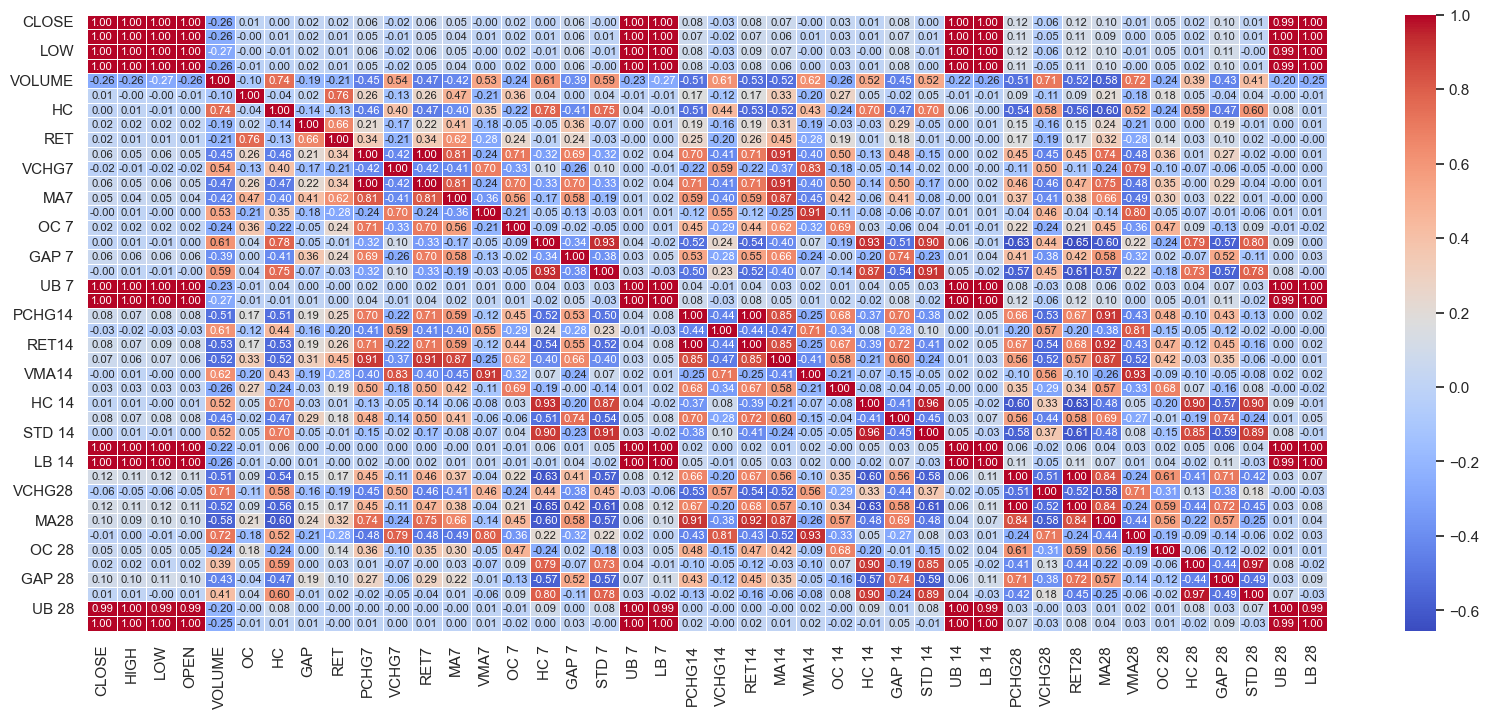

In [16]:
# show all correlations first
sns.heatmap(data.corr(), annot=True, annot_kws={"size": 8}, fmt=".2f", linewidth=.5, cmap="coolwarm", cbar=True)

In [17]:
# drop correlated features

drop_correlated_features = correlated_features(df=data)
drop_correlated_features

{'HC 14',
 'HC 28',
 'HIGH',
 'LB 14',
 'LB 28',
 'LB 7',
 'LOW',
 'MA14',
 'MA28',
 'OPEN',
 'RET14',
 'RET28',
 'RET7',
 'STD 14',
 'STD 28',
 'STD 7',
 'UB 14',
 'UB 28',
 'UB 7',
 'VMA14',
 'VMA28'}

In [18]:
# Drop the highly correlated features
X = data.drop(drop_correlated_features, axis=1)

# record remaining feature names 
feature_names = X.columns
X.head()

,CLOSE,VOLUME,OC,HC,GAP,RET,PCHG7,VCHG7,MA7,VMA7,OC 7,HC 7,GAP 7,PCHG14,VCHG14,OC 14,GAP 14,PCHG28,VCHG28,OC 28,GAP 28
DATE,,,,,,,,,,,,,,,,,,,,,
2015-12-11,170.5914,211173300,-0.0072,0.0131,-0.0122,-0.0196,-0.0319,0.9474,0.9789,1.4022,-0.0010,0.0162,-0.0036,-0.0355,1.2462,-0.0008,-0.0018,-0.0404,1.4478,-0.0003,-0.0012
2015-12-14,171.4532,182385200,0.0041,0.0155,0.0009,0.0050,-0.0132,0.0972,0.9857,1.1927,0.0018,0.0153,-0.0036,-0.0295,1.8089,-0.0004,-0.0017,-0.0384,0.9149,-0.0003,-0.0011
2015-12-15,173.2532,154069600,0.0016,0.0160,0.0089,0.0104,-0.0219,-0.2014,0.9992,1.0455,-0.0008,0.0146,-0.0024,-0.0206,0.5582,-0.0008,-0.0007,-0.0253,0.6011,-0.0001,-0.0008
2015-12-16,175.7883,197017000,0.0080,0.0175,0.0065,0.0145,-0.0015,0.9310,1.0141,1.2242,0.0010,0.0154,-0.0012,-0.0062,2.7902,-0.0001,-0.0003,-0.0101,1.5127,0.0003,-0.0006
2015-12-17,173.1095,173092500,-0.0170,0.0178,0.0018,-0.0154,-0.0101,0.6745,1.0001,1.0129,-0.0018,0.0161,0.0004,-0.0224,3.6383,-0.0014,-0.0002,-0.0247,0.5669,-0.0004,-0.0005


In [19]:
X.columns

Index(['CLOSE', 'VOLUME', 'OC', 'HC', 'GAP', 'RET', 'PCHG7', 'VCHG7', 'MA7',
       'VMA7', 'OC 7', 'HC 7', 'GAP 7', 'PCHG14', 'VCHG14', 'OC 14', 'GAP 14',
       'PCHG28', 'VCHG28', 'OC 28', 'GAP 28'],
      dtype='object')

# Modelling

In [20]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 1989, 498


### Base Model
We now build a base model with default parameters using Pipelines. Dataset needs to be scaled for the model to work properly and all the features should have a similar scale. The scaling can be accomplished by using appropriate transformers. Scaling requirement can however be relaxed for tree-based models.

In [21]:
# Use pipeline to fit the basemodel
basemodel = XGBClassifier(verbosity = 0, silent=True, random_state=42)

basemodel.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
# Predicting the test dataset
y_pred = basemodel.predict(X_test) # gives you the class labels 1, 0,..

# Predict Probabilities 
# gives you the probabilities of each class labels
y_proba = basemodel.predict_proba(X_test)

In [23]:
# accuracy of the model
acc_train = accuracy_score(y_train, basemodel.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 1.0, Test Accuracy: 0.49


### Prediction Quality

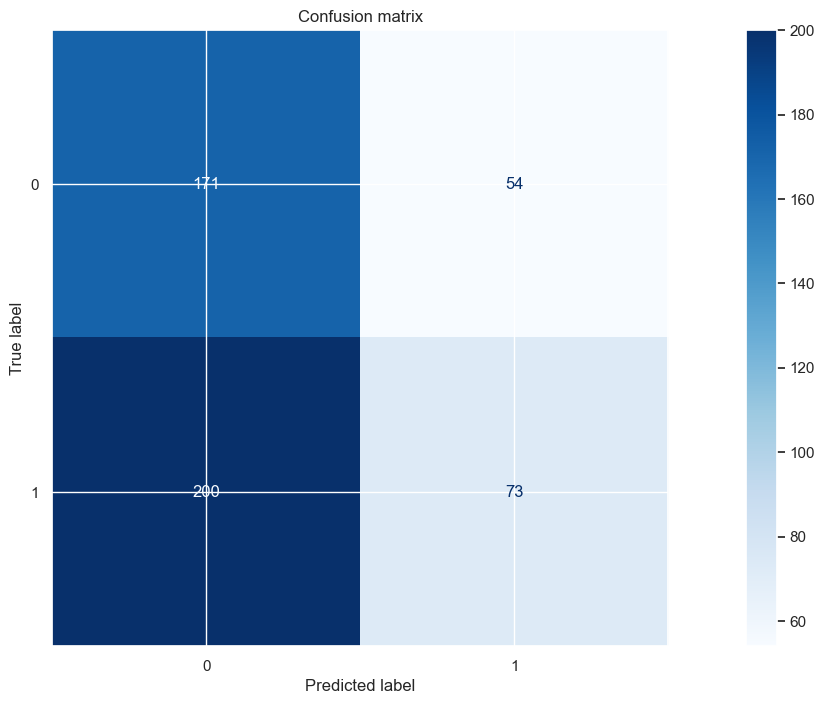

In [24]:
# Display confussion matrix
disp = ConfusionMatrixDisplay.from_estimator(
        basemodel,
        X_test,
        y_test,
        cmap=plt.cm.Blues
    )
plt.title('Confusion matrix')
plt.show()

In [25]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.76      0.57       225
           1       0.57      0.27      0.36       273

    accuracy                           0.49       498
   macro avg       0.52      0.51      0.47       498
weighted avg       0.52      0.49      0.46       498



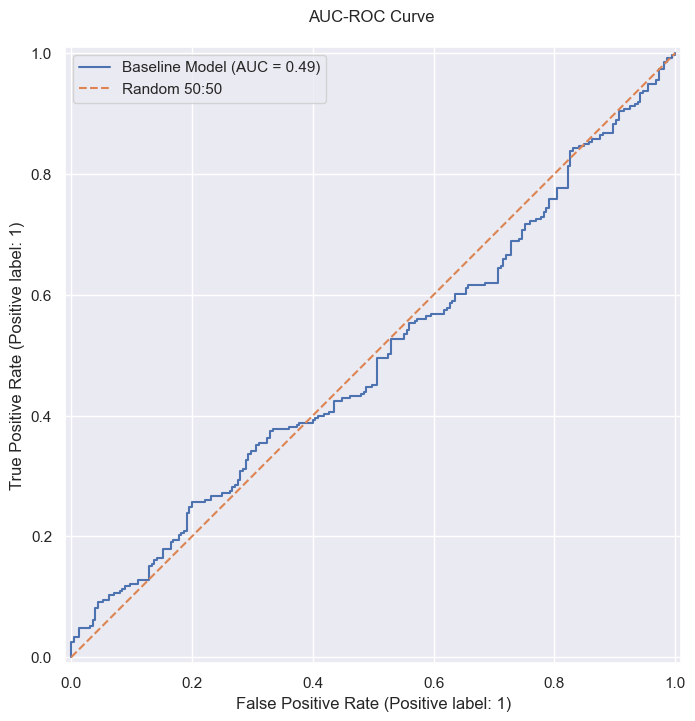

In [26]:
# Display ROCCurve 
disp = RocCurveDisplay.from_estimator(
            basemodel, 
            X_test, 
            y_test,
            name='Baseline Model')
plt.title("AUC-ROC Curve \n")
plt.plot([0,1],[0,1],linestyle="--", label='Random 50:50')
plt.legend()
plt.show()

## Hyperparameter Tuning 

In [27]:
# Cross-validation
tscv = TimeSeriesSplit(n_splits=5, gap=1)

In [28]:
# Get parameters list
basemodel.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': 0,
 'silent': True}

In [29]:
# Perform Gridsearch and fit
param_grid = {'learning_rate': [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
              'max_depth': [3, 4, 5, 6, 8, 10, 12, 15],
              'min_child_weight': [1, 3, 5, 7],
              'gamma': [0.0, 0.1, 0.2 , 0.3, 0.4],
              'colsample_bytree': [0.3, 0.4, 0.5 , 0.7]}

# Perform Gridsearch
rs = RandomizedSearchCV(
                        basemodel,
                        param_grid, 
                        n_iter=100, 
                        scoring='f1', 
                        cv=tscv, 
                        verbose=0
                        )

rs.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=1, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gam...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.3, 0.4, 0.5,
                                                             0.7],
                                        'gamma': [0.0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.05, 0.1, 0.15, 0.2,
                                                          0.25, 0.3],
                                        'max_depth': [3, 4, 5, 6, 8, 10, 12,
                                                      15],
                                        'min_child_weight': [1, 3, 5, 7]},
                   scoring='f1')

### Tuned Model 
Let's now preidict the tuned model (best estimator) with the best search parameter

In [30]:
# predict using the best model
tunedmodel = rs.best_estimator_

# Predict class labels 
y_pred = tunedmodel.predict(X_test)


# Measure Accuracy
acc_train = accuracy_score(y_train, tunedmodel.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

# Print Accuracy
print(f'\n Training Accuracy \t: {acc_train :0.4} \n Test Accuracy \t\t: {acc_test :0.4}')


 Training Accuracy 	: 0.995 
 Test Accuracy 		: 0.5221


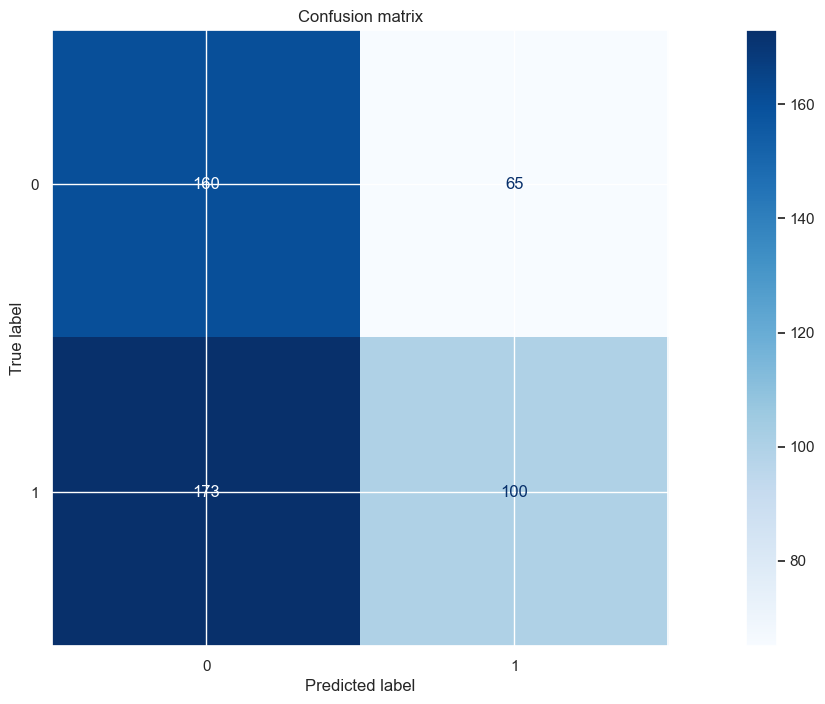

In [31]:
# Display confussion matrix
disp = ConfusionMatrixDisplay.from_estimator(
        tunedmodel,
        X_test,
        y_test,
        # display_labels=tunedmodel.classes_,
        cmap=plt.cm.Blues
    )
plt.title('Confusion matrix')
plt.show()

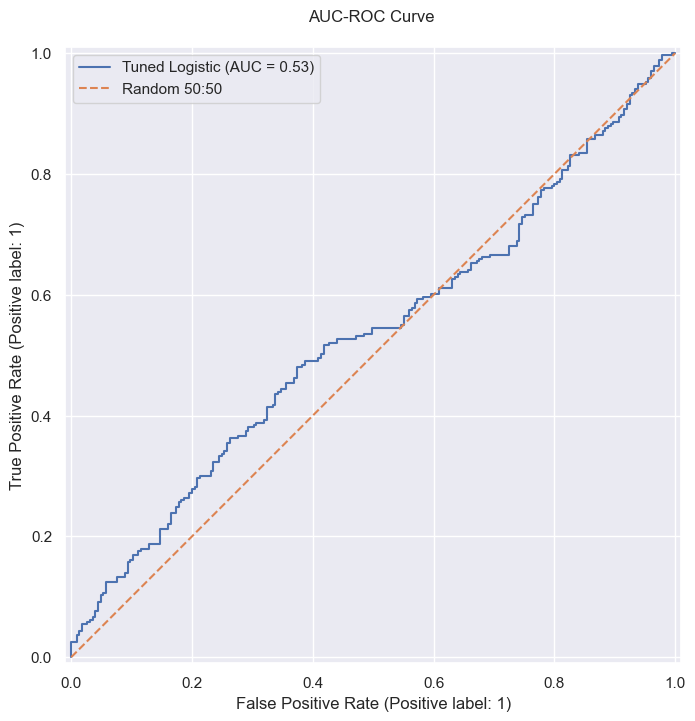

In [32]:
# Display ROCCurve 
disp = RocCurveDisplay.from_estimator(
            tunedmodel, 
            X_test, 
            y_test,
            name='Tuned Logistic')
plt.title("AUC-ROC Curve \n")
plt.plot([0,1],[0,1],linestyle="--", label='Random 50:50')
plt.legend()
plt.show()

In [33]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.71      0.57       225
           1       0.61      0.37      0.46       273

    accuracy                           0.52       498
   macro avg       0.54      0.54      0.52       498
weighted avg       0.55      0.52      0.51       498



# Trading Strategy 

In [34]:
# Subsume into a new dataframe
df1 = data[-len(X_test):].copy()                                  # df[-len(X_test):]
# Remove timezone from index
df1.index = df1.index.tz_localize(None)
df1["SIGNAL"] = tunedmodel.predict(X_test)                      # tunedmodel.predict(X_test)

In [35]:
# Daily Returns - Benchmark return
df1["RETURNS"] = np.log(df["CLOSE"]).diff().fillna(0)

# Strategy Returns - Logistic
df1["STRATEGY"] =  df1["RETURNS"] * df1["SIGNAL"].shift(1).fillna(0)

df1

,CLOSE,HIGH,LOW,OPEN,VOLUME,OC,HC,GAP,RET,PCHG7,VCHG7,RET7,MA7,VMA7,OC 7,HC 7,GAP 7,STD 7,UB 7,LB 7,PCHG14,VCHG14,RET14,MA14,VMA14,OC 14,HC 14,GAP 14,STD 14,UB 14,LB 14,PCHG28,VCHG28,RET28,MA28,VMA28,OC 28,HC 28,GAP 28,STD 28,UB 28,LB 28,SIGNAL,RETURNS,STRATEGY
DATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07,425.9222,426.5656,423.5632,424.7135,64256100,0.0028,0.0071,-0.0000,0.0028,0.0639,-0.4015,0.0620,1.0214,0.7604,0.0050,0.0091,0.0039,0.0058,434.2573,399.7649,0.0156,-0.3132,0.0155,1.0321,0.6794,-0.0008,0.0112,0.0019,0.0104,429.2774,396.1066,0.0196,-0.3035,0.0194,1.0235,0.7084,0.0000,0.0122,0.0007,0.0091,431.0574,401.1956,0,0.0028,0.0000
2023-11-08,426.2342,427.0531,423.9142,426.5267,61746000,-0.0007,0.0074,0.0014,0.0007,0.0521,-0.2867,0.0508,1.0148,0.7627,0.0042,0.0086,0.0031,0.0063,434.7725,405.2825,0.0254,-0.4911,0.0251,1.0309,0.6836,-0.0001,0.0106,0.0019,0.0100,431.5092,395.3817,0.0229,-0.4636,0.0226,1.0235,0.6954,0.0004,0.0120,0.0005,0.0090,431.8789,401.0544,1,0.0007,0.0000
2023-11-09,422.9101,427.4235,422.4812,427.3845,83174400,-0.0105,0.0117,0.0027,-0.0078,0.0374,0.0440,0.0367,1.0017,1.0211,0.0020,0.0088,0.0033,0.0085,432.1511,412.2598,0.0300,-0.3288,0.0296,1.0207,0.9515,-0.0000,0.0105,0.0022,0.0095,432.9808,395.6717,0.0153,-0.0074,0.0152,1.0149,0.9369,-0.0001,0.0121,0.0007,0.0092,432.2976,401.0903,1,-0.0078,-0.0078
2023-11-10,429.5095,429.8215,422.9003,424.9962,89462200,0.0106,0.0164,0.0049,0.0155,0.0425,-0.0878,0.0416,1.0113,1.1151,0.0023,0.0094,0.0037,0.0092,430.7092,418.7011,0.0479,-0.0280,0.0468,1.0331,1.0256,0.0006,0.0105,0.0028,0.0101,435.8371,395.6214,0.0451,-0.1378,0.0441,1.0291,1.0136,0.0006,0.0120,0.0010,0.0092,433.5157,401.1966,0,0.0155,0.0155
2023-11-13,429.1001,430.2114,427.3747,428.1643,52236100,0.0022,0.0066,-0.0031,-0.0010,0.0219,-0.4498,0.0217,1.0072,0.7047,0.0012,0.0089,0.0019,0.0074,431.0715,420.9651,0.0391,-0.3351,0.0383,1.0293,0.6120,0.0006,0.0103,0.0022,0.0101,438.1248,395.6398,0.0366,-0.4027,0.0359,1.0268,0.6004,0.0005,0.0119,0.0009,0.0091,434.5894,401.2042,1,-0.0010,-0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,685.2400,685.5400,682.1200,682.7300,63339800,0.0037,0.0050,0.0081,0.0117,0.0372,-0.4271,0.0366,1.0186,0.8919,0.0025,0.0076,0.0028,0.0060,686.2795,659.1576,0.0241,-0.1205,0.0238,1.0252,0.7749,-0.0008,0.0115,0.0025,0.0106,684.1746,652.5968,0.0424,-0.3787,0.0415,1.0277,0.8072,-0.0002,0.0092,0.0017,0.0078,679.5251,654.0477,0,0.0117,0.0117
2025-10-28,687.0600,688.9100,684.8300,687.0500,61738100,0.0000,0.0060,0.0026,0.0027,0.0341,-0.3602,0.0336,1.0164,0.9347,0.0014,0.0068,0.0034,0.0060,690.9847,660.9295,0.0207,0.0171,0.0205,1.0264,0.7546,-0.0011,0.0115,0.0026,0.0105,687.9683,650.7959,0.0403,-0.3175,0.0395,1.0289,0.7972,-0.0002,0.0092,0.0016,0.0078,682.3466,653.1284,1,0.0027,0.0000
2025-10-29,687.3900,689.7000,682.8700,688.7200,85657100,-0.0019,0.0100,0.0024,0.0005,0.0240,0.4160,0.0237,1.0135,1.2299,0.0003,0.0072,0.0031,0.0057,694.8042,661.7072,0.0242,0.2880,0.0239,1.0251,1.0298,-0.0010,0.0117,0.0027,0.0105,691.4810,649.6019,0.0357,-0.1255,0.0351,1.0281,1.1124,-0.0003,0.0093,0.0016,0.0078,684.8704,652.2968,0,0.0005,0.0005


In [36]:
# performance analysis
qs.reports.html(
    df1["STRATEGY"],
    df1["RETURNS"],
    title='Strategy Performance',
    output='xgbclassifier2.html'
)